Perform Linear Regression

In [ ]:
"""Importing Libraries"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Reading csv file
file_path = "data_scaling_skewed_data.csv"
df = pd.read_csv(file_path)

df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [43]:
df.shape

(100, 7)

In [45]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            100 non-null    int64  
 1   Study_Hours           100 non-null    float64
 2   Age                   100 non-null    int64  
 3   Attendance            97 non-null     float64
 4   Family_Income         100 non-null    float64
 5   Internet_Usage_Hours  98 non-null     float64
 6   Exam_Score            100 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 5.6 KB


,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,50.500000,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,29.011492,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,1.000000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,25.750000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,50.500000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,75.250000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,100.000000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


In [46]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [47]:
df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].median()
)

In [48]:
df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(
    df["Internet_Usage_Hours"].median()
)

In [49]:
df.isnull().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

In [50]:
df = df.drop(columns=["Student_ID"])
df.head()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,4.79,25,68.22,26401.83,5.13,68.46
1,2.99,25,72.62,29899.43,10.14,58.53
2,2.76,24,87.15,84956.82,6.63,50.72
3,2.76,20,87.14,15797.16,0.99,72.44
4,9.30,18,87.15,44019.48,2.10,60.92


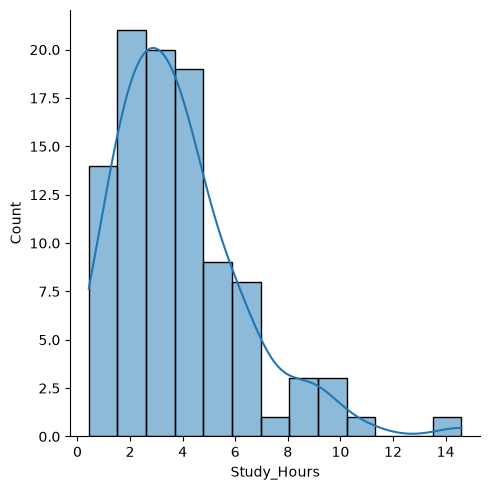

In [67]:
sns.displot(x=df["Study_Hours"], kde=True)
plt.show()

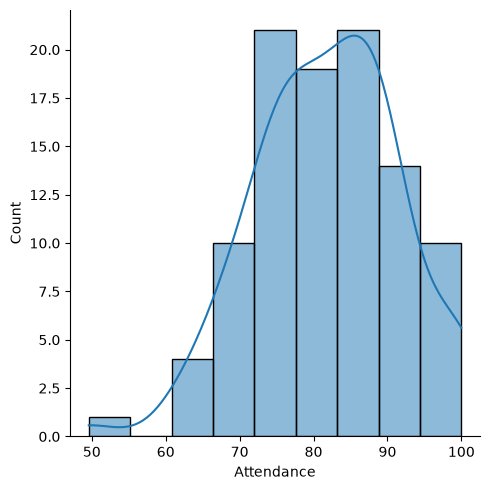

In [68]:
sns.displot(x=df["Attendance"], kde=True)
plt.show()

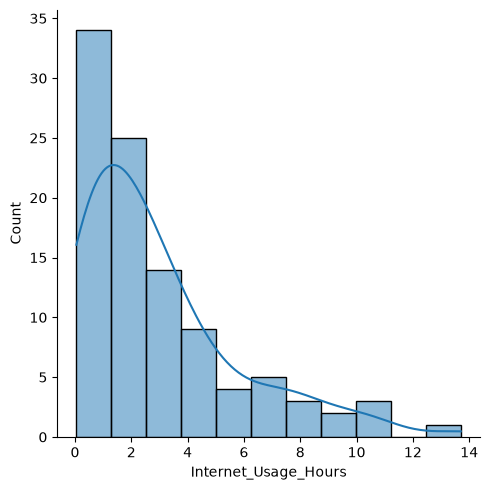

In [69]:
sns.displot(x=df["Internet_Usage_Hours"], kde=True)
plt.show()

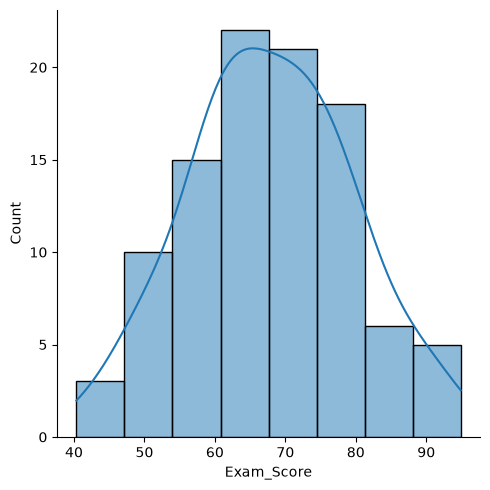

In [86]:
sns.displot(x=df["Exam_Score"], kde=True)
plt.show()

In [75]:
df.skew(numeric_only=True)

Study_Hours             1.466644
Age                    -0.104205
Attendance             -0.282655
Family_Income           2.242351
Internet_Usage_Hours    1.502271
Exam_Score              0.038566
dtype: float64

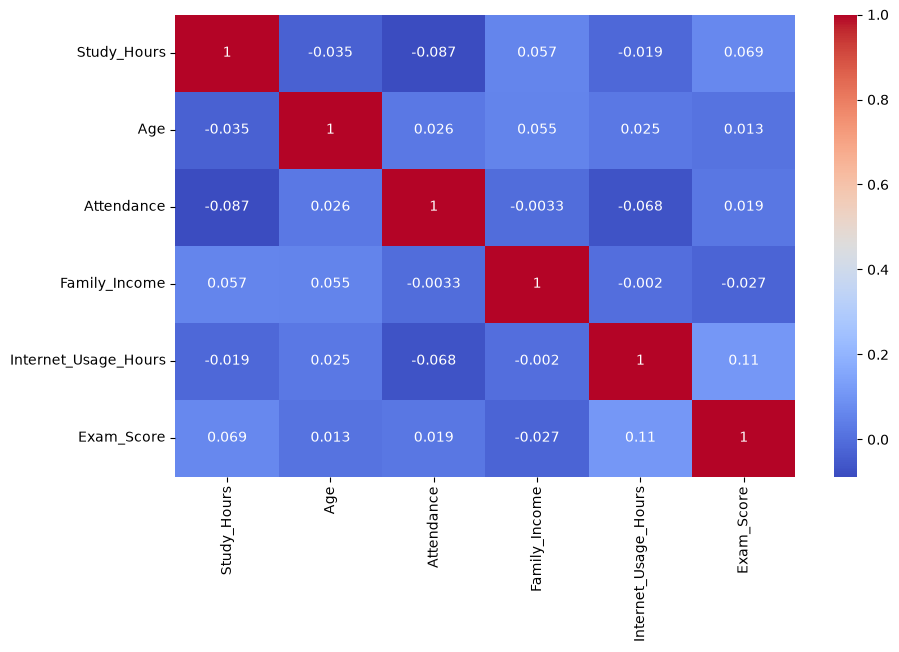

In [78]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))

sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.show()

In [51]:
X=df[["Study_Hours","Attendance","Internet_Usage_Hours"]]
y=df["Exam_Score"]

In [58]:
X.shape  

(100, 3)

In [60]:
y.shape 

(100,)

In [87]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [88]:
X_train.shape

(80, 3)

In [89]:
X_test.shape

(20, 3)

In [90]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.63,0.06,0.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendance','Internet_Usage_Hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,60.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [97]:
y_pred = model.predict(X_test)
y_pred

array([67.49340143, 67.56750155, 66.50603577, 71.56638841, 69.02310819,
       68.57266102, 65.9525406 , 69.45646462, 66.86624127, 68.94936239,
       68.54050382, 69.40733524, 68.87841311, 69.17335921, 69.50745987,
       72.00642622, 66.13582702, 68.6280225 , 70.33447571, 68.05590832])

In [96]:
compare = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

compare

,Actual,Predicted
0,66.09,67.493401
1,55.47,67.567502
2,71.04,66.506036
3,48.34,71.566388
4,60.84,69.023108
5,79.02,68.572661
6,53.22,65.952541
7,73.48,69.456465
8,69.90,66.866241
9,68.46,68.949362


In [98]:
print("Intercept:", model.intercept_)

print("Study Hours coefficient:", model.coef_[0])
print("Attendance coefficient:", model.coef_[1])
print("Internet Usage coefficient:", model.coef_[2])

Intercept: 60.153940260154876
Study Hours coefficient: 0.6320829017178159
Attendance coefficient: 0.061006838879322844
Internet Usage coefficient: 0.3130328416712469


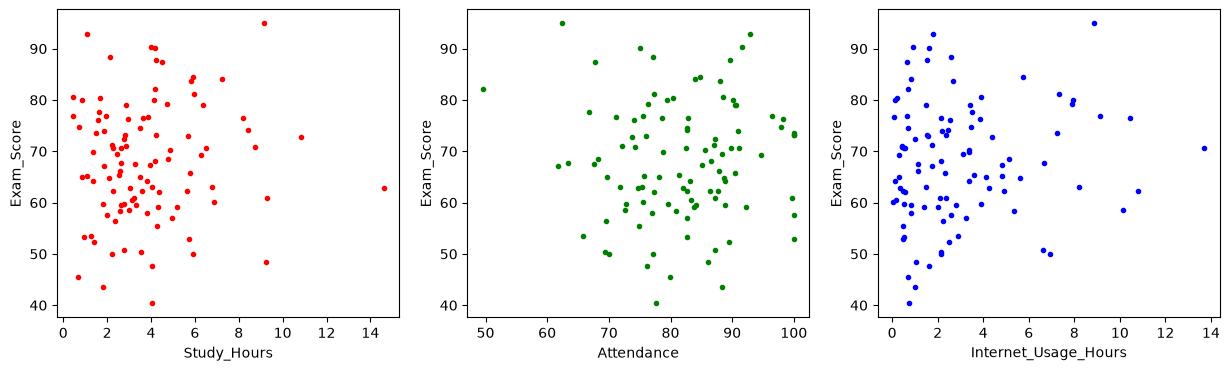

In [84]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


fig = plt.figure(figsize=(15,4))
gs = GridSpec(1, 3)

# Study_Hours vs Exam_Score
ax = fig.add_subplot(gs[0])
ax.scatter(df["Study_Hours"], df["Exam_Score"], color="red", marker=".")
ax.set_xlabel("Study_Hours")
ax.set_ylabel("Exam_Score")

# Attendance vs Exam_Score
ax = fig.add_subplot(gs[1])
ax.scatter(df["Attendance"], df["Exam_Score"], color="green", marker=".")
ax.set_xlabel("Attendance")
ax.set_ylabel("Exam_Score")

# Internet_Usage_Hours vs Exam_Score
ax = fig.add_subplot(gs[2])
ax.scatter(df["Internet_Usage_Hours"], df["Exam_Score"], color="blue", marker=".")
ax.set_xlabel("Internet_Usage_Hours")
ax.set_ylabel("Exam_Score")

plt.show()